# SSM-4 aside — hybrid attention–SSM models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/tracks/state-space-models/ssm4-aside-hybrid-models.ipynb)

*A companion to [SSM-4](ssm4-gate-spectrum.ipynb): an SSM's fixed-size state makes it cheap but a lossy recaller, while attention recalls exactly at the cost of a growing cache. This shows the gap, and why frontier models interleave the two. Optional.*

> Grounding: [Zoology](https://arxiv.org/abs/2312.04927) (Arora et al., 2023) measures the recall gap between attention and efficient models that carry a fixed-size state, on a multi-query associative-recall task. The hybrids that close it interleave the two block types: [Jamba](https://arxiv.org/abs/2403.19887) (Lieber et al., 2024) alternates Transformer and Mamba blocks, and [Samba](https://arxiv.org/abs/2406.07522) (Ren et al., 2024) alternates Mamba with sliding-window attention.

## 1. Two memories on one recall task

An SSM layer and a linear-attention layer carry the same kind of memory: a fixed-size state that every token folds into and reads from. SSM-4 wrote it as one recurrence, $\mathbf{S}_t=\alpha_t\,\mathbf{S}_{t-1}+\beta_t\,(\text{write}_t)\,\phi(\mathbf{k}_t)^\top$, where $\mathbf{S}_t$ is a matrix whose size is set once and never grows with the sequence. That is the source of the efficiency. Running the layer costs $O(1)$ memory and $O(T)$ time over a length-$T$ sequence, so context can be long and cheap.

The same bounded state is also the limit. The state stores associations by superposing outer products, which is M1's Hebbian memory, and a fixed-size sum of outer products holds only about as many clean associations as its dimension. Past that point the reads interfere. This is M1's crosstalk at the scale of a real sequence: once the number of distinct things the layer must remember exceeds the state's capacity, recall of any particular one degrades.

Attention pays the opposite price. It keeps every key and value in a cache that grows with the sequence, $O(T)$ memory, and reads by addressing the cache directly, so it recovers any earlier token exactly however many there are.

The demo puts both memories on one synthetic associative-recall task, the setup Zoology uses to measure the gap. Store $m$ key–value pairs, then query each key and read its value back. One memory is the fixed-size outer-product state; the other is softmax attention holding all $m$ pairs. Sweep $m$ and score how often the right value returns.

m=   4 pairs   fixed-state recall=1.000   attention recall=1.000
m=   8 pairs   fixed-state recall=1.000   attention recall=1.000
m=  16 pairs   fixed-state recall=1.000   attention recall=1.000
m=  24 pairs   fixed-state recall=0.990   attention recall=1.000
m=  32 pairs   fixed-state recall=0.984   attention recall=1.000
m=  48 pairs   fixed-state recall=0.904   attention recall=1.000
m=  64 pairs   fixed-state recall=0.820   attention recall=1.000
m=  96 pairs   fixed-state recall=0.646   attention recall=1.000
m= 128 pairs   fixed-state recall=0.453   attention recall=1.000

at m=128: fixed state = 1024 numbers (constant);  attention cache = 8192 numbers (grows with m)


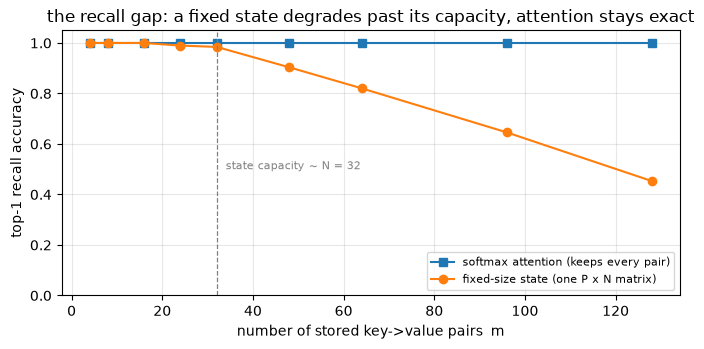

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
N, P = 32, 32          # key feature dim N (the state's capacity) and value dim P, both fixed
beta = 12.0            # softmax sharpness: a low enough temperature to address the matched key

def recall_accuracy(m, seed):
    g = torch.Generator().manual_seed(seed)
    K = torch.randn(m, N, generator=g); K = K / K.norm(dim=1, keepdim=True)   # m unit keys
    V = torch.randn(m, P, generator=g); V = V / V.norm(dim=1, keepdim=True)   # m unit values

    # Fixed-size outer-product state (M1's Hebbian write, M3's linear-attention / SSM memory):
    # S = sum_j v_j k_j^T is a P x N matrix, and its size never grows with m.
    S = V.t() @ K
    read_state = K @ S.t()                              # query every key back: (m, P)

    # Softmax attention: keep all m pairs (the growing cache) and read exactly.
    A = torch.softmax(beta * (K @ K.t()), dim=1)
    read_attn = A @ V

    # Score top-1 recall: decode each read to its nearest stored value.
    def top1(read):
        pred = (read @ V.t()).argmax(dim=1)
        return (pred == torch.arange(m)).float().mean().item()
    return top1(read_state), top1(read_attn)

ms = [4, 8, 16, 24, 32, 48, 64, 96, 128]
state_acc, attn_acc = [], []
for m in ms:
    rows = [recall_accuracy(m, s) for s in range(8)]    # average over 8 random stores
    state_acc.append(sum(r[0] for r in rows) / len(rows))
    attn_acc.append(sum(r[1] for r in rows) / len(rows))

for m, a, b in zip(ms, state_acc, attn_acc):
    print(f"m={m:4d} pairs   fixed-state recall={a:.3f}   attention recall={b:.3f}")

state_numbers = P * N                    # constant, independent of m
cache_numbers = ms[-1] * (N + P)         # grows with m
print(f"\nat m={ms[-1]}: fixed state = {state_numbers} numbers (constant);  "
      f"attention cache = {cache_numbers} numbers (grows with m)")

plt.figure(figsize=(7, 3.6))
plt.plot(ms, attn_acc, "s-", label="softmax attention (keeps every pair)")
plt.plot(ms, state_acc, "o-", label="fixed-size state (one P x N matrix)")
plt.axvline(N, ls="--", c="gray", lw=0.9)
plt.text(N + 2, 0.5, f"state capacity ~ N = {N}", color="gray", fontsize=8)
plt.xlabel("number of stored key->value pairs  m")
plt.ylabel("top-1 recall accuracy")
plt.title("the recall gap: a fixed state degrades past its capacity, attention stays exact")
plt.ylim(0, 1.05); plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

The two curves start together and split at the state's capacity. Up to about $m=N$ stored pairs the fixed-size state recalls almost everything, because $N$-dimensional keys leave enough room to keep the associations close to orthogonal. Past $N$ the outer products overlap and the reads come back as contaminated blends, so accuracy falls, dropping under one half by $m=128$ with $N=32$. Attention holds exact recall across the whole sweep, because it never compressed the pairs: each one still sits in the cache and can be addressed on its own. The printed sizes are the cost of that exactness. The state stays at $N\times P$ numbers however many pairs arrive, while the cache grows with each pair, and by $m=128$ it holds eight times as many. A layer with a bounded state buys cheap long context and gives up exact recall; a layer that keeps the cache buys exact recall and gives up the bound.

## 2. Why frontier models interleave the two

The plot frames the design question. Most of a long context is material a bounded state summarizes well: the running topic, recent syntax, the gist of what came before. A little of it needs exact recall of a specific earlier token, a name or a number or a definition introduced once and wanted again, and that is what the fixed state loses as the context grows. Zoology measured this and attributed most of the quality difference between efficient models and attention to the recall gap.

A hybrid stack takes both memories instead of choosing one. It fills most of its depth with SSM or linear-attention blocks, which carry the sequence cheaply, and inserts a smaller number of full-attention blocks whose growing cache supplies the exact recall the state cannot. The attention layers are rare enough that their cache stays a fraction of a pure Transformer's, and the SSM layers do the bulk of the mixing, so the stack keeps close to linear cost while recovering the recall the plot shows the state losing.

This is the arrangement behind current hybrid models. Jamba interleaves Transformer and Mamba blocks in a fixed ratio; Samba alternates Mamba with sliding-window attention; the same pattern runs through recent systems such as Jet-Nemotron and Nemotron-Nano-2. The ratio and the placement differ across them, but the reason is the one on the plot: pairing a cheap forgetful memory with an exact expensive one recovers the useful behavior of both.

## What this shows

- **A fixed-size state and a growing cache sit at opposite ends of one recall trade.** The outer-product state costs $O(1)$ memory and recalls cleanly only up to about its own dimension in stored associations; past that its superposed reads blur, which is M1's crosstalk at sequence scale. Attention costs $O(T)$ memory and recalls any stored pair exactly, because it keeps them all.
- **The gap is the reason hybrids exist.** An SSM layer is a good default for most of a long context and a poor one for exact lookup of a specific earlier token. Interleaving a few attention layers into a stack of SSM layers buys that recall back while keeping most of the efficiency, which is what Zoology found and what Jamba and Samba build.
- **It is the same $\alpha_t$ this track has been turning.** SSM-4 read the gate across its range and every setting still lived inside one bounded state. The hybrid answer is not another gate value; it is placing a second kind of memory next to the first.

**Honest scope.** This is a tiny synthetic associative-recall toy, in the spirit of Zoology's multi-query task but far smaller. It stores random key–value pairs in one step and reads them once, with no sequence model, no training, and no language. The fixed-size memory is a plain outer-product state with the identity feature map, so its capacity is M1's key dimension exactly; a real SSM adds a feature map, an input-dependent gate, and many channels, which move the capacity without removing the bound. The attention side uses a sharp softmax so it addresses the matched key, and a trained model learns that sharpness rather than being handed it. The point is the shape of the trade, an $O(1)$ state that loses recall past its capacity against an $O(T)$ cache that keeps it, and not a ranking: real hybrids interleave many layers, tune the attention-to-SSM ratio, and add sliding windows and other machinery this toy leaves out. Zoology's measurements were on gated-convolution models; the fixed-state mechanism it isolates is the one shared with the SSMs this track built.